<img src="https://github.com/Multiomics-Analytics-Group/course_protein_language_modeling/blob/main/img/nb_logo.png?raw=1" width="600">

#### Colab Setup

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Multiomics-Analytics-Group/course_protein_language_modeling/blob/main/notebooks/interpretability.ipynb)

This notebook adapts ideas from Anthropic's [Towards Monosemanticity](https://transformer-circuits.pub/2023/monosemantic-features) (Bricken et al., 2023) and from [InterPLM](https://www.biorxiv.org/content/10.1101/2024.11.14.623630v1) (Simon & Zou, 2024), which applied the same technique to protein language models, to the [ProtT5/ESM2 embeddings notebook](https://colab.research.google.com/github/Multiomics-Analytics-Group/course_protein_language_modeling/blob/main/notebooks/embeddings.ipynb) from earlier in this course.

In [1]:
# uncomment the below to install dependencies for colab
!pip install "transformers[torch]" biopython > /dev/null

<h3><span style="color:red">Important</span></h3>
If you are running in Google Colab, change the Notebook settings to use `GPU`.

Just follow **Edit** > **Notebook settings** or **Runtime** > **Change runtime type** and select **GPU** as Hardware accelerator.

![gpu.png](../img/gpu.png)


---

# Mechanistic Interpretability of Protein Language Models via Sparse Autoencoders

So far in this course we have treated protein language model (pLM) representations mostly as a **black box**:
- In `model_training.ipynb` we fine-tuned ESM-2 end-to-end for a classification task, again without inspecting what the model learned internally in order to solve it.
- In `embeddings.ipynb` we generated fixed-size vector representations (embeddings) of $\beta$-$lactamase$ variants using ProtT5.
- In `prediction.ipynb` we used those embeddings, without asking what any individual dimension means, to train regressors that predict variant effect.
- In `prot_design.ipynb` we used a pLM to *generate* new sequences, trusting that its internal representations of "what a protein looks like" are good enough to produce plausible designs.


> **What has the model actually learned about protein biology, and can we trust it?**

This notebook introduces **mechanistic interpretability**, a growing subfield of ML interpretability that tries to reverse-engineer what individual computational units inside a neural network represent, and applies the **Sparse Autoencoder (SAE)**, to a protein language model. We will train an SAE on ESM2's internal activations for the same $\beta$-$lactamase$ dataset used earlier in the course, and check whether the features it discovers line up with things we already know about $\beta$-$lactamase$ biology (e.g., its catalytic residues).

**Goals for this notebook:**
- Understand *why* individual neurons in a pLM are hard to interpret directly (superposition & polysemanticity).
- Understand how a Sparse Autoencoder recovers more interpretable, in some cases monosemantic features from those activations.
- Train a small SAE on ESM2 residue-level representations of TEM $\beta$-$lactamase$ variants.
- Check whether any of the learned features track known biology: catalytic residues, amino acid identity, etc.
- Discuss some of the *Limitations*

The notebook follows part of the workflow in [Gujral et al. 2025](https://www.pnas.org/doi/10.1073/pnas.2506316122):

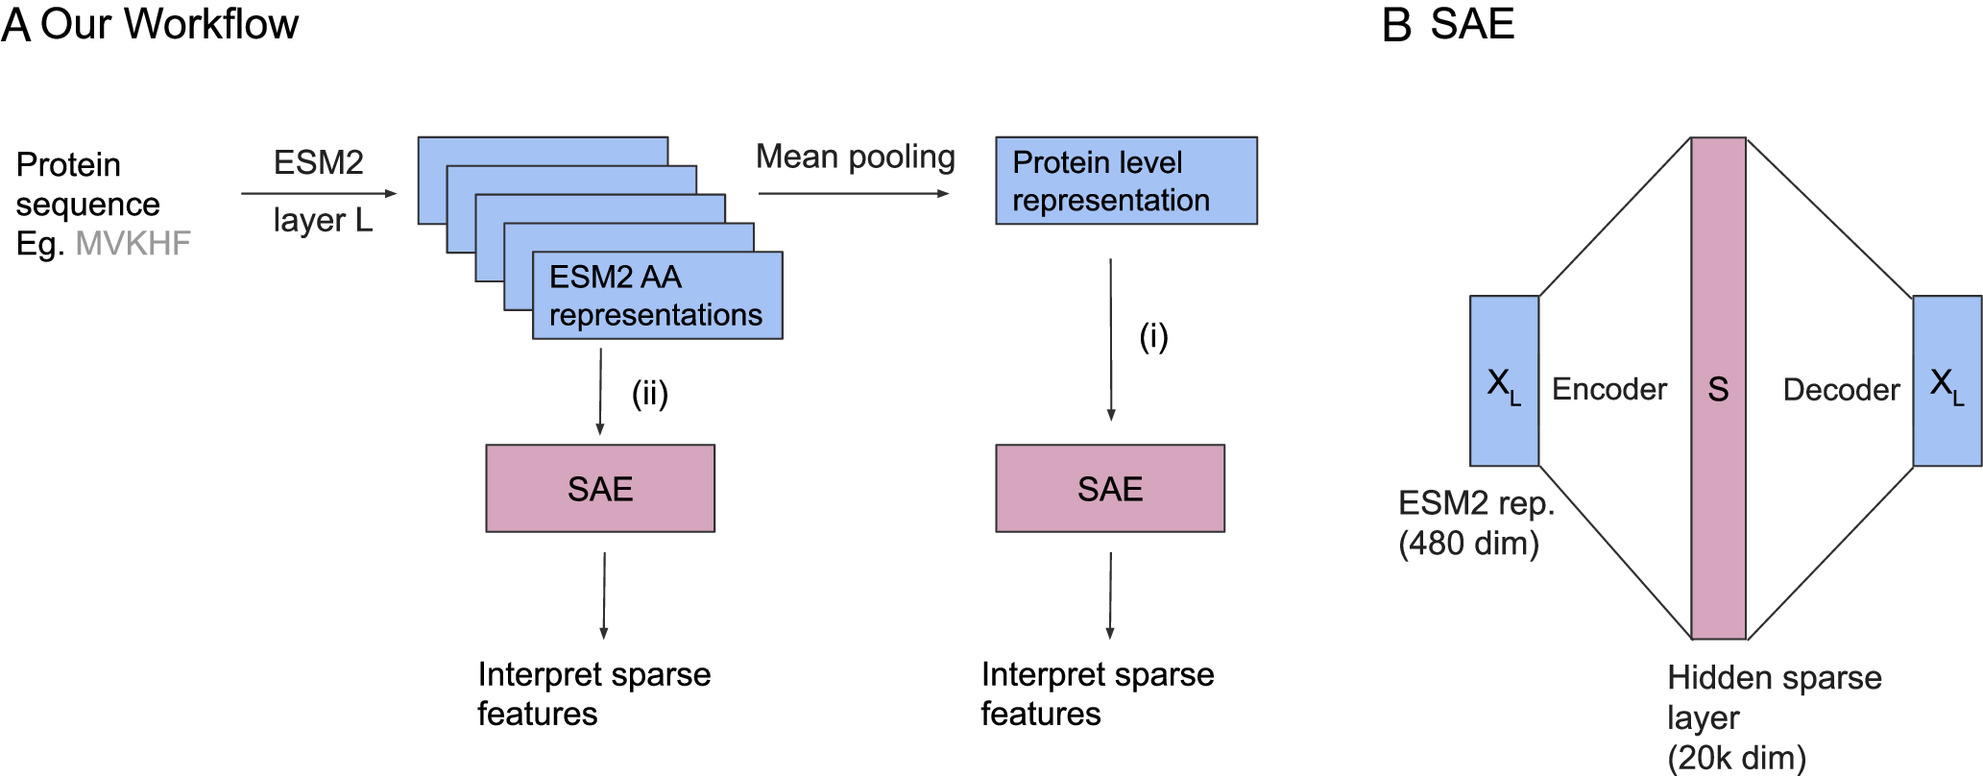



---

## The Data: P62593 $\beta$-lactamase Variants (again)

We will reuse the exact same dataset as `embeddings.ipynb` and `prediction.ipynb`: ~5,000 single-point mutants of the TEM-1 $\beta$-lactamase enzyme (UniProt [P62593](https://www.uniprot.org/uniprotkb/P62593)) [Gray et al. (2018)](https://www.cell.com/cell-systems/pdfExtended/S2405-4712(17)30492-1).

**Biological context:** TEM-1 $\beta$-lactamase is a bacterial enzyme that confers resistance to $\beta$-lactam antibiotics (like penicillins) by hydrolyzing their characteristic $\beta$-lactam ring. Decades of structural and biochemical work (see reviews by [Fisher & Mobashery, 2009](https://doi.org/10.1007/s00223-009-9265-3) and [Palzkill, 2018](https://doi.org/10.3389/fmolb.2018.00016)) have identified a set of residues that make up its catalytic machinery:

| Residue | Role |
|---|---|
| **Ser70** | Catalytic nucleophile, part of the S-X-X-K motif |
| **Lys73** | General base, part of the S-X-X-K motif |
| **Ser130** | Part of the S-D-N loop, positions the substrate |
| **Glu166** | Part of the Omega loop, activates the catalytic water for deacylation |
| **Lys234** | Part of the K-T-G motif, stabilizes the oxyanion intermediate |

We will use this as **ground truth about which residues matter mechanistically**. If ESM2 has learned something about how this enzyme works, we might expect some of the SAE's features to be especially sensitive to these positions.


In [2]:
# Set up working directory and download the same FASTA file used in embeddings.ipynb
!curl -o P62593.fasta https://dl.fbaipublicfiles.com/fair-esm/examples/P62593.fasta

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1719k  100 1719k    0     0  2072k      0 --:--:-- --:--:-- --:--:-- 2072k


In [7]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from transformers import AutoTokenizer, AutoModel

# check whether GPU is available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")

Matplotlib is building the font cache; this may take a moment.
/opt/anaconda3/envs/plm_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cpu


In [8]:
def read_fasta(fasta_path: str, limit: int = 0) -> dict:
    '''
    reads in fasta file and returns a dictionary with primary id/sequence key/value pairs
    (recall this function from embeddings.ipynb)
    '''
    seqs = {}
    with open(fasta_path) as handle:
        for record in SeqIO.parse(handle, "fasta"):
            seqs[record.id] = str(record.seq)

    if limit > 0:
        seqs = dict(list(seqs.items())[:limit])

    example_id = next(iter(seqs))
    print(f"Read {len(seqs)} sequences.")
    print(f"Example:\nKey: {example_id}\nValue: {seqs[example_id]}")

    return seqs


def parse_mutation(key: str):
    '''
    parses the `{index}|beta-lactamase_{mutation}|{scaled_variant_effect}` key format
    used throughout this course (see embeddings.ipynb / prediction.ipynb) and returns
    (wt_aa, position, mut_aa, scaled_effect)
    '''
    _, mut_field, effect = key.split('|')
    mutation = mut_field.split('_')[-1]
    wt_aa, mut_aa = mutation[0], mutation[-1]
    position = int(mutation[1:-1])
    return wt_aa, position, mut_aa, float(effect)

<div class="warning" style='background-color:#E9D8FD; color: #69337A; border-left: solid #805AD5 4px; border-radius: 4px; padding:0.7em;'>
<span>
<p style='margin-top:1em; text-align:center'><b>NOTE</b></p>
<p style='margin-left:1em;'>
    Unlike <code>embeddings.ipynb</code>, we need <b>per-residue</b> representations rather than a single mean-pooled vector per protein, since we want to know exactly which residues activate which features. To keep runtime reasonable on a free Colab GPU (or CPU), we only use a subset of the ~5,400 variants. Feel free to increase <code>limit</code> if you have more compute available.
</p>
</span>
</div>

In [9]:
# keep this small enough to comfortably run on a single GPU (or CPU) within the course session
fasta_output = read_fasta('P62593.fasta', limit=300)

Read 300 sequences.
Example:
Key: 0|beta-lactamase_P20P|1.581033423
Value: MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRVDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDHVTRLDRWEPELNEAIPNDERDTTMPAAMATTLRKLLTGELLTLASRQQLIDWMEADKVAGPLLRSALPAGWFIADKSGAGERGSRGIIAALGPDGKPSRIVVIYTTGSQATMDERNRQIAEIGASLIKHW


In [10]:
# Key catalytic / motif residues of TEM-1 beta-lactamase (Ambler numbering)
CATALYTIC_RESIDUES = {
    70: "Ser70 - catalytic nucleophile (S-X-X-K motif)",
    73: "Lys73 - general base (S-X-X-K motif)",
    130: "Ser130 - S-D-N loop, substrate positioning",
    166: "Glu166 - Omega loop, activates catalytic water",
    234: "Lys234 - K-T-G motif, oxyanion stabilization",
}

---

## The Model: ESM2

We use [ESM-2](https://github.com/facebookresearch/esm) (recall `model_training.ipynb`) to obtain its **internal, per-residue hidden states**. We use one of the smaller checkpoints (`esm2_t12_35M_UR50D`), and we will look at a **middle transformer layer**, which tends to encode a rich mix of biophysical, structural, and evolutionary features (very early layers mostly encode local sequence context, and very late layers are shaped mostly by the pretraining objective itself).

In [11]:
model_checkpoint = "facebook/esm2_t12_35M_UR50D"
LAYER = 6  # a middle layer out of the model's 12 transformer layers

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModel.from_pretrained(model_checkpoint, output_hidden_states=True).to(device)
model = model.eval()

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 9977.32it/s]
[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### `get_residue_embeddings()` Extracting per-residue activations

This plays the same role as `get_embeddings()` in `embeddings.ipynb`, except that instead of mean-pooling over the sequence to get one vector per protein, we keep **one activation vector per residue**, along with some bookkeeping (which sequence and position it came from, and the amino acid identity), which we will need later to check whether SAE features track biology.

In [12]:
@torch.no_grad()
def get_residue_embeddings(seqs: dict, layer: int = LAYER, max_batch: int = 16):
    '''
    Runs ESM2 over each sequence and collects per-residue hidden states from `layer`.

    Args:
        seqs: dictionary of {key: sequence}
        layer: which hidden_states layer to extract (0 = input embeddings)
        max_batch: number of sequences per forward pass

    Returns:
        embeddings: np.ndarray of shape (total_residues, d_model)
        meta_df: pd.DataFrame with one row per residue (key, position, residue, is_catalytic)
    '''
    records = list(seqs.items())
    all_embs, meta = [], []

    for i in range(0, len(records), max_batch):
        batch = records[i:i + max_batch]
        keys, sequences = zip(*batch)

        tokenized = tokenizer(list(sequences), return_tensors='pt', padding=True).to(device)
        outputs = model(**tokenized)
        hidden = outputs.hidden_states[layer]  # (batch, seq_len, d_model)

        for b, (key, sequence) in enumerate(zip(keys, sequences)):
            length = int(tokenized['attention_mask'][b].sum().item())
            # drop the special [CLS]/[EOS] tokens ESM2 adds at the start/end
            seq_hidden = hidden[b, 1:length - 1].detach().cpu().numpy()
            all_embs.append(seq_hidden)

            for pos, vec in enumerate(seq_hidden, start=1):
                meta.append({
                    'key': key,
                    'position': pos,
                    'residue': sequence[pos - 1],
                })

        print(f'Processed {min(i + max_batch, len(records))}/{len(records)} sequences')

    embeddings = np.concatenate(all_embs, axis=0)
    meta_df = pd.DataFrame(meta)
    meta_df['is_catalytic'] = meta_df['position'].isin(CATALYTIC_RESIDUES.keys())

    return embeddings, meta_df

In [13]:
# extract per-residue activations
residue_embeddings, meta_df = get_residue_embeddings(fasta_output)

print(f"\nCollected {residue_embeddings.shape[0]} residue activations of dimension {residue_embeddings.shape[1]}")
meta_df.head()

Processed 16/300 sequences
Processed 32/300 sequences
Processed 48/300 sequences
Processed 64/300 sequences
Processed 80/300 sequences
Processed 96/300 sequences
Processed 112/300 sequences
Processed 128/300 sequences
Processed 144/300 sequences
Processed 160/300 sequences
Processed 176/300 sequences
Processed 192/300 sequences
Processed 208/300 sequences
Processed 224/300 sequences
Processed 240/300 sequences
Processed 256/300 sequences
Processed 272/300 sequences
Processed 288/300 sequences
Processed 300/300 sequences

Collected 85800 residue activations of dimension 480


,key,position,residue,is_catalytic
0,0|beta-lactamase_P20P|1.581033423,1,M,False
1,0|beta-lactamase_P20P|1.581033423,2,S,False
2,0|beta-lactamase_P20P|1.581033423,3,I,False
3,0|beta-lactamase_P20P|1.581033423,4,Q,False
4,0|beta-lactamase_P20P|1.581033423,5,H,False


---

## Building a Sparse Autoencoder in PyTorch

To keep it simple and readable we use an untied encoder/decoder and a single shared bias that is subtracted before encoding and added back after decoding (Bricken et al., 2023) to help the SAE center the data it is reconstructing.

In [14]:
class SparseAutoencoder(nn.Module):
    '''
    A minimal Sparse Autoencoder (SAE) for interpreting internal model activations.

    - encoder: linear + ReLU projecting activations into an *overcomplete*
      latent space (more latents than input dimensions)
    - decoder: linear projection back to the original activation space
    - the L1 penalty applied to the latent activations during training 
      is what encourages sparsity, i.e., only a
      handful of latents should be "on" for any given residue
    '''
    def __init__(self, d_model: int, expansion_factor: int = 8):
        super().__init__()
        d_hidden = d_model * expansion_factor
        self.encoder = nn.Linear(d_model, d_hidden)
        self.decoder = nn.Linear(d_hidden, d_model, bias=False)
        self.decoder_bias = nn.Parameter(torch.zeros(d_model))

    def encode(self, x):
        return F.relu(self.encoder(x - self.decoder_bias))

    def forward(self, x):
        latents = self.encode(x)
        reconstruction = self.decoder(latents) + self.decoder_bias
        return reconstruction, latents

### `train_sae()` Training with a reconstruction + sparsity objective

The loss combines mean-squared reconstruction error with an L1 penalty on the latent activations. `l1_coeff` controls the trade-off: too small and the SAE just learns an (uninterpretable) ordinary autoencoder; too large and it collapses to predicting near-zero for everything. We also track `avg_active_latents`, the average number of latents with nonzero activation per residue (its **L0 "norm"**) — this is the number we actually want to be small, the L1 penalty is only a convenient proxy for it we can backpropagate through.

In [15]:
def train_sae(
    embeddings: np.ndarray,
    expansion_factor: int = 8,
    l1_coeff: float = 1e-3,
    epochs: int = 20,
    batch_size: int = 256,
    lr: float = 1e-3,
):
    d_model = embeddings.shape[1]
    sae = SparseAutoencoder(d_model, expansion_factor).to(device)
    optimizer = torch.optim.Adam(sae.parameters(), lr=lr)

    data = torch.tensor(embeddings, dtype=torch.float32)
    n = data.shape[0]

    history = []
    for epoch in range(epochs):
        perm = torch.randperm(n)
        total_recon, total_l1, total_l0 = 0.0, 0.0, 0.0

        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            batch = data[idx].to(device)

            reconstruction, latents = sae(batch)
            recon_loss = F.mse_loss(reconstruction, batch)
            l1_loss = latents.abs().mean()
            loss = recon_loss + l1_coeff * l1_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_recon += recon_loss.item() * len(idx)
            total_l1 += l1_loss.item() * len(idx)
            total_l0 += (latents > 0).float().sum(dim=1).mean().item() * len(idx)

        history.append({
            'epoch': epoch,
            'recon_loss': total_recon / n,
            'l1': total_l1 / n,
            'avg_active_latents': total_l0 / n,
        })

    return sae, pd.DataFrame(history)

In [16]:
sae, history = train_sae(residue_embeddings)
history.tail()

,epoch,recon_loss,l1,avg_active_latents
15,15,0.001056,0.172469,788.186737
16,16,0.001068,0.164926,763.576492
17,17,0.001219,0.156973,736.797541
18,18,0.001076,0.149107,706.862296
19,19,0.000995,0.143039,681.632529


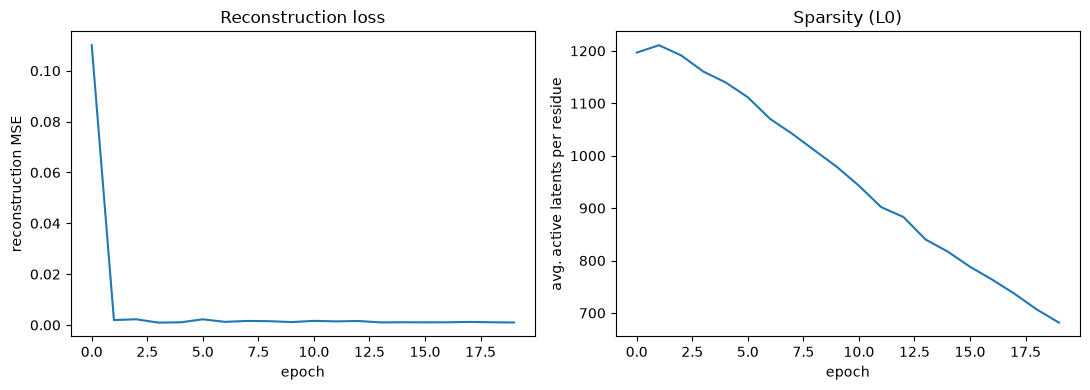

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(history['epoch'], history['recon_loss'])
ax1.set_xlabel('epoch')
ax1.set_ylabel('reconstruction MSE')
ax1.set_title('Reconstruction loss')

ax2.plot(history['epoch'], history['avg_active_latents'])
ax2.set_xlabel('epoch')
ax2.set_ylabel('avg. active latents per residue')
ax2.set_title('Sparsity (L0)')

plt.tight_layout()
plt.show()

A good SAE should settle on a reconstruction error that is low (it isn't throwing away most of the information in the original activation) while the number of active latents per residue stays a small fraction of the total latent dimension (e.g., a few dozen active out of a few thousand). If reconstruction loss won't go down, try lowering `l1_coeff`; if the number of active latents stays high, try raising it.

---

## Do the SAE's features correspond to biology?

We now have, for every residue in our dataset, a vector of latent activations. Most of them should be zero. Let's look at what turns individual latents on, and check whether any of them line up with the known catalytic residues we highlighted earlier, or with something as simple as amino acid identity.

In [18]:
sae.eval()
with torch.no_grad():
    _, latents = sae(torch.tensor(residue_embeddings, dtype=torch.float32).to(device))
latents = latents.cpu().numpy()

print(f"Latent activations shape: {latents.shape}")

# fraction of residues on which each latent is active at all
active_frac = (latents > 0).mean(axis=0)
print(f"On average, a latent is active on {active_frac.mean()*100:.2f}% of residues")

# "alive" latents: neither always-off (dead) nor firing on almost everything (uninformative)
alive = np.where((active_frac > 0.001) & (active_frac < 0.2))[0]
print(f"{len(alive)} alive latents out of {latents.shape[1]} total")

Latent activations shape: (85800, 3840)
On average, a latent is active on 17.32% of residues
1098 alive latents out of 3840 total


### Are any features enriched at the catalytic residues?

For each alive latent, we compare its average activation at the five catalytic positions we identified earlier against its average activation everywhere else. A large ratio means that latent tends to activate much more strongly right at the enzyme's active site than elsewhere in the sequence.

In [19]:
is_catalytic = meta_df['is_catalytic'].values

records = []
for feat in alive:
    acts = latents[:, feat]
    cat_mean = acts[is_catalytic].mean()
    noncat_mean = acts[~is_catalytic].mean()
    enrichment = (cat_mean + 1e-8) / (noncat_mean + 1e-8)
    records.append({
        'feature': feat,
        'catalytic_activation': cat_mean,
        'background_activation': noncat_mean,
        'enrichment': enrichment,
    })

enrichment_df = pd.DataFrame(records).sort_values('enrichment', ascending=False)
enrichment_df.head(10)

,feature,catalytic_activation,background_activation,enrichment
132,448,0.398453,0.007902,50.422855
473,1633,0.509555,0.016037,31.774687
143,491,0.449076,0.014435,31.110100
368,1270,0.330405,0.015447,21.389610
131,446,0.157706,0.009016,17.491032
465,1605,0.171247,0.010628,16.112677
220,726,0.347071,0.024122,14.388036
366,1263,0.327842,0.023007,14.249807
406,1397,0.255870,0.018557,13.788262
913,3192,0.291885,0.021283,13.714779


Let's visualize the top hit: how does this latent's activation vary along the length of a single sequence, compared to where the known catalytic residues are?

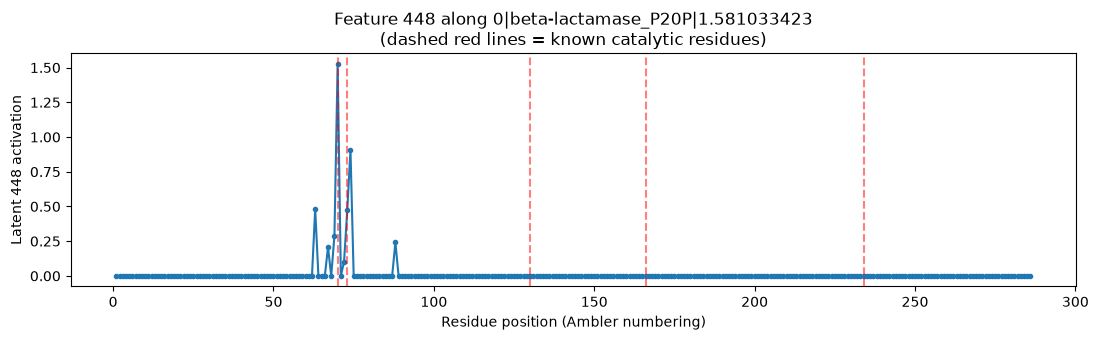

In [20]:
top_feature = int(enrichment_df.iloc[0]['feature'])

# visualize this feature's activation along one example sequence
example_key = next(iter(fasta_output.keys()))
example_mask = (meta_df['key'] == example_key).values
positions = meta_df.loc[example_mask, 'position'].values
activations = latents[example_mask, top_feature]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(positions, activations, marker='.')
for pos, label in CATALYTIC_RESIDUES.items():
    ax.axvline(pos, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Residue position (Ambler numbering)')
ax.set_ylabel(f'Latent {top_feature} activation')
ax.set_title(f'Feature {top_feature} along {example_key}\n(dashed red lines = known catalytic residues)')
plt.tight_layout()
plt.show()

<div class="warning" style='background-color:#E9D8FD; color: #69337A; border-left: solid #805AD5 4px; border-radius: 4px; padding:0.7em;'>
<span>
<p style='margin-top:1em; text-align:center'><b>NOTE</b></p>
<p style='margin-left:1em;'>
    Whether the top feature clearly tracks the catalytic residues will depend on the random seed, the amount of training, and how many sequences you used. This is an exploration, not a guaranteed result! Try changing <code>LAYER</code>, <code>expansion_factor</code>, or <code>l1_coeff</code> and re-running to see how the discovered features change. This sensitivity to hyperparameters is itself an important limitation of this technique.
</p>
</span>
</div>

### Amino-acid selective features

Enrichment at five specific positions out of hundreds is a hard thing to ask an unsupervised model to discover from only a few hundred sequences. A pattern that tends to show up much more reliably, and which was also reported by [InterPLM](https://www.biorxiv.org/content/10.1101/2024.11.14.623630v1) for ESM2, is that a good fraction of the *simplest* latents act as **amino acid identity detectors** — turning on almost exclusively when a specific residue type is present, regardless of its position or role. Let's check for that too.

In [21]:
aa_records = []
for feat in alive:
    active_mask = latents[:, feat] > 0
    if active_mask.sum() < 20:  # skip latents that barely activate at all
        continue

    aa_counts = meta_df.loc[active_mask, 'residue'].value_counts(normalize=True)
    aa_records.append({
        'feature': feat,
        'top_amino_acid': aa_counts.index[0],
        'purity': aa_counts.iloc[0],     # fraction of activations that are this one amino acid
        'n_active': int(active_mask.sum()),
    })

aa_df = pd.DataFrame(aa_records).sort_values('purity', ascending=False)
aa_df.head(10)

,feature,top_amino_acid,purity,n_active
952,3337,I,1.0,600
723,2573,A,1.0,300
464,1600,F,1.0,886
875,3068,W,1.0,300
1008,3556,R,1.0,301
456,1580,L,1.0,2087
857,3022,W,1.0,300
452,1563,Q,1.0,273
311,1122,I,1.0,300
318,1141,S,1.0,300


If this worked as expected, you should see several latents near the top of this table with `purity` close to 1.0 — i.e., latents that activate almost exclusively on a single amino acid type (tryptophan and cysteine, being the rarest and most distinctive amino acids, are common examples). This is a small but concrete example of a genuinely **monosemantic, human-interpretable feature** recovered directly from a pLM's internal activations, with no supervision at all.

---

<div class="warning" style='background-color:#E9D8FD; color: #69337A; border-left: solid #805AD5 4px; border-radius: 4px; padding:0.7em;'>
<span>
<p style='margin-top:1em; text-align:center'><b>NOTE</b></p>
<p style='margin-left:1em;'>
    Because we are training on a relatively small, single-protein-family dataset for the sake of keeping this notebook lightweight, our SAE will find far coarser and less reliable features than the ones reported in dedicated interpretability studies (like InterPLM) that train on millions of residues across many protein families.
</p>
</span>
</div>

## References
- Bricken, T. et al. (2023). [Towards Monosemanticity: Decomposing Language Models With Dictionary Learning](https://transformer-circuits.pub/2023/monosemantic-features). Transformer Circuits Thread.
- Gujral O. et al. (2025)[Sparse autoencoders uncover biologically interpretable features in protein language model representations](https://www.pnas.org/doi/10.1073/pnas.2506316122). Workflow
- Cunningham, H. et al. (2023). [Sparse Autoencoders Find Highly Interpretable Features in Language Models](https://arxiv.org/abs/2309.08600).
- Simon, E. & Zou, J. (2024). [InterPLM: Discovering Interpretable Features in Protein Language Models via Sparse Autoencoders](https://www.biorxiv.org/content/10.1101/2024.11.14.623630v1).
- Fisher, J. F. & Mobashery, S. (2009). [Enzymology of Bacterial Resistance](https://doi.org/10.1007/s00223-009-9265-3).
- Palzkill, T. (2018). [Structural and Mechanistic Basis for Extended-Spectrum Drug-Resistance Mutations in Altering the Specificity of TEM, CTX-M, and KPC β-lactamases](https://doi.org/10.3389/fmolb.2018.00016).
- Gray, V. E. et al. (2018). [Elucidating the Molecular Determinants of Aβ Aggregation with Deep Mutational Scanning](https://www.cell.com/cell-systems/pdfExtended/S2405-4712(17)30492-1) (source of the deep mutational scan dataset used throughout this course).
- Andrea H. et al. (2026) [Toward the Explainability of Protein Language Models](https://arxiv.org/abs/2506.19532)
